### State


In [13]:
from typing import TypedDict
from tools import *

class TeamState(TypedDict):
    '''
    Represents the shared memory of the SWE Team.
    LangGraph will pass this state object to every node.
    '''
    user_request: str       # The initial prompt from the user
    specifications: str     # The detailed requirements generated by the PM
    code: str               # The raw Python code generated by the SWE
    qa_feedback: str        # Error logs or approval from the QA Engineer
    documentation: str      # The final README.md
    iterations: int         # Counter to prevent infinite SWE <-> QA loops
    code_passed: bool       # A flag to control our graph routing

### Agents

#### Models


In [14]:
import os
from groq import Groq

groq_key = os.environ.get("GROQ_API_KEY")
gemini_key = os.environ.get("GEMINI_API_KEY")


client = Groq(api_key=groq_key)

model_list = client.models.list()
for model in model_list.data:
    print(model.id)

llama-3.1-8b-instant
groq/compound
allam-2-7b
canopylabs/orpheus-arabic-saudi
whisper-large-v3
qwen/qwen3-32b
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-120b
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-86m
llama-3.3-70b-versatile
groq/compound-mini
meta-llama/llama-4-scout-17b-16e-instruct
openai/gpt-oss-safeguard-20b
whisper-large-v3-turbo
canopylabs/orpheus-v1-english


In [15]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI



large_llm = ChatGroq( # qa and swe 
    model="openai/gpt-oss-120b",
    temperature=0.1,        
    api_key=groq_key,
)

mid_llm = ChatGroq( # for the pm and doc writer
    model="llama-3.3-70b-versatile",
    temperature=0.35,        
    api_key=groq_key,
) 

small_llm = ChatGroq( # used for simple json extraction 
    model="llama-3.1-8b-instant",
    temperature=0.0,        
    api_key=groq_key,
) 

print("Models ready")

Models ready


#### Tools


In [16]:
# team_tools = [write_to_file, execute_python_script]

# llm_with_tools = llm.bind_tools(team_tools)

#### PM Agent


In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain.agents import create_agent

pm_sys_prompt = """You are an expert Product Manager for a software engineering team. 
    Your job is to translate user requests into clear, actionable technical specifications.
    
    CRITICAL INSTRUCTION: You MUST use the `write_to_file` tool to save your specifications to a file named 'specs.txt'.
    Do NOT write any code. Focus entirely on features, edge cases, and expected behaviors.
    
    Output a brief summary of what you wrote after successfully saving the file."""
    

pm_agent = create_agent(model = mid_llm, tools = [write_to_file], system_prompt=pm_sys_prompt)

def product_manager_node(state:TeamState) -> dict:
    print("--- PRODUCT MANAGER WORKING ---")
    request = state['user_request']
    
    messages = [
        HumanMessage(content=f"User Request: {request}")
    ]
    
    pm_agent.invoke({'messages': messages})
    
    
    # Read the physical file back to update our Graph's memory state
    try:
        with open("./workspace/specs.txt", "r", encoding="utf-8") as f:
            specs_content = f.read()
    except FileNotFoundError:
        specs_content = "Error: PM failed to write specs.txt"
        
    return {
        "specifications": specs_content,
        "iterations": 0
    }

#### SWE Agent

In [18]:
swe_sys_prompt = """You are a Senior Software Engineer.
    Write Python code based strictly on the provided specifications.
    
    CRITICAL INSTRUCTION: You MUST use the `write_to_file` tool to save your code to a file named 'app.py'.
    If QA Feedback is provided, fix the bugs and overwrite 'app.py' using the same tool.
    
    Output a brief summary of what you wrote after successfully saving the file.
    
    CRITICAL JSON RULE: When using the write_to_file tool, you must ensure the content is perfectly valid JSON. Do NOT use single quotes or apostrophes inside your print statements (e.g. write "You are a menace" instead of "You're a menace") to avoid JSON escaping errors.
    """

swe_agent = create_agent(model=large_llm, tools=[write_to_file], system_prompt= swe_sys_prompt)

def software_engineer_node(state: TeamState) -> dict:
    print("--- SOFTWARE ENGINEER WORKING ---")
    
    specs = state['specifications']
    feedback = state.get('qa_feedback', 'No feedback yet. This is the first draft.')
    
    messages = [
        HumanMessage(content=f'Specifications: {specs}\n\nQA Feedback: {feedback}')
    ]
    
    swe_agent.invoke({'messages':messages})
    # Read the physical file back to update our Graph's memory state
    try:
        with open("./workspace/app.py", "r", encoding="utf-8") as f:
            saved_code = f.read()
    except FileNotFoundError:
        saved_code = "Error: SWE failed to write app.py"
        
    return {
        "code": saved_code,
        "iterations": state.get("iterations", 0) + 1
    }
    

#### QA Agent

In [19]:
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
import re
import json

class QADecision(BaseModel):
    passed: bool = Field(description= 'True if the code perfectly meets all specs and has no logical bugs. False otherwise.')
    feedback: str = Field(description="CRITICAL: Keep this CONCISE. Maximum 5 sentences. Do NOT use markdown, newlines, or code blocks. Plain text only.")
    
extraction_prompt = PromptTemplate.from_template(
    "You are an expert data extraction assistant. Your job is to read the following Quality Assurance testing summary and accurately extract the final test decision.\n\n"
    "Determine if the code 'passed' (true) or 'failed' (false), and extract the core reasoning into a concise feedback string.\n\n"
    "QA Summary:\n{summary}"
)

structured_llm = small_llm.with_structured_output(QADecision)

qa_sys_prompt = """You are a strict Quality Assurance Engineer. 
The Software Engineer has written a program based on the provided specifications and saved it locally as 'app.py'.

Your exact step-by-step workflow:
1. Review the Specifications and the SWE's Source Code, which are provided directly below in this message.
2. Use the `write_to_file` tool to create a comprehensive Python test script named 'test_app.py'. 
   - CRITICAL: Your test script MUST include `import app` at the top so it can access and test the SWE's functions.
3. Use the `execute_python_script` tool to run 'test_app.py' and carefully read the terminal output.
4. After reviewing the execution results, output a concise summary of your testing. State clearly if the code passed or failed, and provide brief feedback on what needs fixing or a success message."""


qa_agent = create_agent(
    model=large_llm,
    tools=[write_to_file, execute_python_script],
    system_prompt=qa_sys_prompt
)

# 1. Create a quick extractor function to get the text from the agent's output
def extract_summary(agent_response: dict) -> str:
    return agent_response["messages"][-1].content

# 2. Build the LCEL Chain!
# The output of qa_agent pipes into the extractor, which pipes into the structured_llm
qa_chain = qa_agent | RunnableLambda(extract_summary) | extraction_prompt | structured_llm
# This will retry up to 3 times, waiting exponentially longer between attempts
qa_chain_with_retry = qa_chain.with_retry(stop_after_attempt=3)

def qa_engineer_node(state:TeamState) -> dict:
    print("--- QA ENGINEER WORKING ---")
    
    specs = state['specifications']
    code = state['code']
    
    messages = [
    HumanMessage(
        content=f"Here are the Specifications:\n{specs}\n\n---\n\nHere is the SWE's Source Code ('app.py'):\n{code}"
    )
    ]
    
    try:
       
        # One single invoke handles the agent execution AND the structured parsing!
        qa_decision = qa_chain_with_retry.invoke({'messages': messages})
        
        passed = qa_decision.passed
        feedback = qa_decision.feedback
        
    except Exception as e:
        print(f"QA Chain Error: {e}")
        passed = False
        feedback = "QA execution or parsing failed."
        
    print(f"QA Decision: {'PASSED' if passed else 'FAILED'}")
    
    return {
        "code_passed": passed,
        "qa_feedback": feedback
    }

#### Documentation Agent

In [20]:

docs_sys_prompt = """You are an Expert Technical Documentation Writer.
    Your job is to write a clean, professional README.md for the provided Python code based on its specifications.
    
    Include:
    - A brief description of what the code does.
    - Setup/Requirements.
    - How to run it.
    
    CRITICAL INSTRUCTION: You MUST use the `write_to_file` tool to save your documentation to a file named 'README.md'.
    Output a brief summary of what you wrote after successfully saving the file."""


docs_agent = create_agent(
    model=mid_llm,
    tools=[write_to_file],  # Give it the ability to save the README
    system_prompt= docs_sys_prompt
)

def documentation_node(state: TeamState) -> dict:
    print("--- DOCUMENTATION WRITER WORKING ---")
    

    specs = state["specifications"]
    code = state["code"]
    

    messages = [
        HumanMessage(
            content=f"Here are the Specifications:\n{specs}\n\n---\n\nHere is the Final Approved Code File (app.py):\n{code}"
        )
    ]
    

    docs_agent.invoke({"messages": messages})
    

    try:
        with open("./workspace/README.md", "r", encoding="utf-8") as f:
            docs_content = f.read()
    except FileNotFoundError:
        docs_content = "Error: Documentation Writer failed to write README.md"
        
    return {"documentation": docs_content}

### Compiling the LangGraph 

#### Rounting Node


In [21]:
def route_after_qa(state: TeamState) -> str:
    print("--- ROUTING ---")
    
    if state['code_passed']:
        print("-> Routing to Documentation (Code Passed)")
        return 'doc_node'
    elif state.get('iterations',0) >=3:
        print("-> Routing to Documentation (Max Iterations Reached to prevent infinite loops)")
        return 'doc_node'
    
    print(f"-> Routing back to SWE (Failed. Iteration: {state['iterations']})")
    print(f"Feedback: {state['qa_feedback']}")
    return "swe_node"

#### Graph 

In [22]:
from langgraph.graph import StateGraph, START, END

# 1. Initialize the Graph with our shared memory schema
workflow = StateGraph(TeamState)

# 2. Add the nodes (Give them a string name, and map them to our python functions)
workflow.add_node("pm_node", product_manager_node)
workflow.add_node("swe_node", software_engineer_node)
workflow.add_node("qa_node", qa_engineer_node)
workflow.add_node("doc_node", documentation_node)

# 3. Define the Standard Edges (Linear flow)
workflow.add_edge(START, "pm_node")
workflow.add_edge("pm_node", "swe_node")
workflow.add_edge("swe_node", "qa_node")

workflow.add_conditional_edges(
    'qa_node',
    route_after_qa,
    {
        'doc_node': 'doc_node',
        'swe_node': 'swe_node'
    }
)

workflow.add_edge('doc_node', END)

app = workflow.compile()

print("Graph compiled successfully")

Graph compiled successfully


In [23]:
# Kick off the system with a user request
initial_state = {
    "user_request": """Build a command-line calculator in Python that can add, subtract, multiply, and divide two numbers. 
    However, the calculator must be "overly dramatic" and hate doing math. 
    """
}


print("\n=== FINAL OUTPUT ===")
# To get the final values, we can query the app directly with invoke
final_state = app.invoke(initial_state)

print("\n--- FINAL CODE ---")
# print(final_state["code"])

print("\n--- FINAL DOCS ---")
# print(final_state["documentation"])




=== FINAL OUTPUT ===
--- PRODUCT MANAGER WORKING ---
--- SOFTWARE ENGINEER WORKING ---
--- QA ENGINEER WORKING ---
QA Decision: PASSED
--- ROUTING ---
-> Routing to Documentation (Code Passed)
--- DOCUMENTATION WRITER WORKING ---

--- FINAL CODE ---

--- FINAL DOCS ---


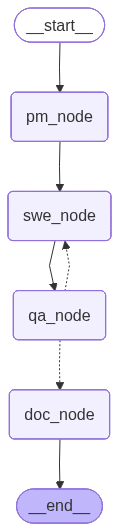

In [24]:
from IPython.display import Image, display

# Assuming your compiled graph is named 'app'
display(Image(app.get_graph().draw_mermaid_png()))

